In [1]:
import os

os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from tensorflow.keras.datasets import fashion_mnist
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [3]:
train_data.shape, train_labels.shape, test_data.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [4]:
train_data[0].shape, train_labels[0].shape

((28, 28), ())

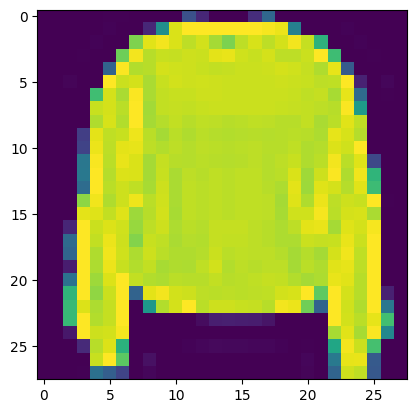

In [5]:
plt.imshow(train_data[7])

In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
len(class_names)

10

Text(0.5, 1.0, 'T-shirt/top')

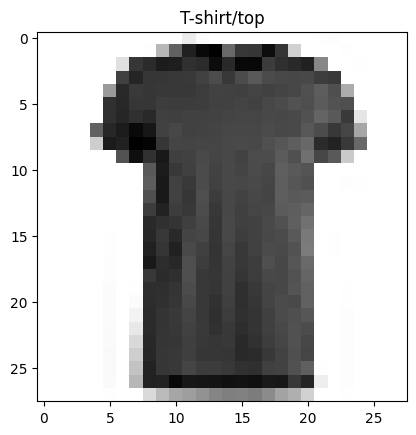

In [7]:
plt.imshow(train_data[17], cmap=plt.cm.binary)
plt.title(class_names[train_labels[17]])

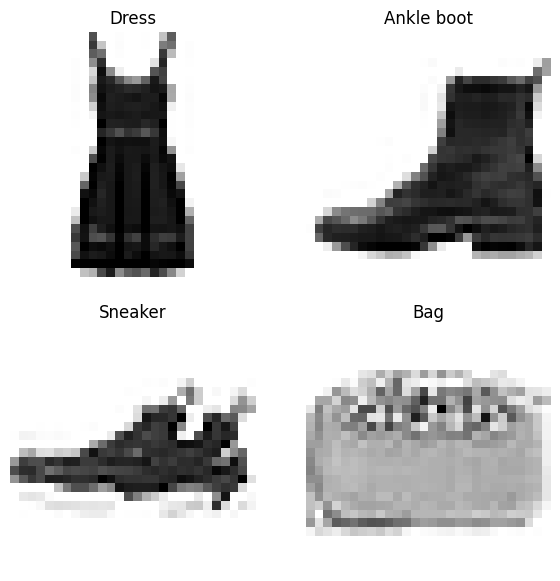

In [8]:
import random
plt.figure(figsize=(7, 7))
for i in range(4):
    ax = plt.subplot(2, 2, i + 1)
    rand_index = random.choice(range(len(train_data)))
    plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
    plt.title(class_names[train_labels[rand_index]])
    plt.axis("off")

In [9]:
tf.random.set_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(4, activation=tf.nn.relu),
    tf.keras.layers.Dense(4, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history = model.fit(train_data, train_labels, epochs=10, validation_data=(test_data, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 603us/step - accuracy: 0.0981 - loss: 2.3082 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 570us/step - accuracy: 0.0974 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3034
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 534us/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 555us/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 499us/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 514us/step - accuracy: 0.0973 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - accuracy: 0.0973 -

In [10]:
train_data.min(), train_data.max()

(np.uint8(0), np.uint8(255))

In [11]:
train_data = train_data / 255.0
test_data = test_data / 255.0
test_data.min(), test_data.max()

(np.float64(0.0), np.float64(1.0))

In [12]:
tf.random.set_seed(42)

model_2 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(16, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

model_2.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history_2 = model_2.fit(train_data, train_labels, epochs=20, validation_data=(test_data, test_labels))


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 789us/step - accuracy: 0.8004 - loss: 0.5709 - val_accuracy: 0.8424 - val_loss: 0.4536
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - accuracy: 0.8554 - loss: 0.4107 - val_accuracy: 0.8483 - val_loss: 0.4167
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 703us/step - accuracy: 0.8676 - loss: 0.3709 - val_accuracy: 0.8509 - val_loss: 0.4071
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 689us/step - accuracy: 0.8757 - loss: 0.3446 - val_accuracy: 0.8559 - val_loss: 0.3907
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 736us/step - accuracy: 0.8813 - loss: 0.3261 - val_accuracy: 0.8587 - val_loss: 0.3825
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/step - accuracy: 0.8872 - loss: 0.3112 - val_accuracy: 0.8620 - val_loss: 0.3734
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 709us/step - accuracy: 0.8910 - loss: 0.2992 - val_accuracy: 0.8638 - val_loss: 0.3659
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 748us/step - accuracy: 0.8942 -

<Axes: title={'center': 'Normalized data'}>

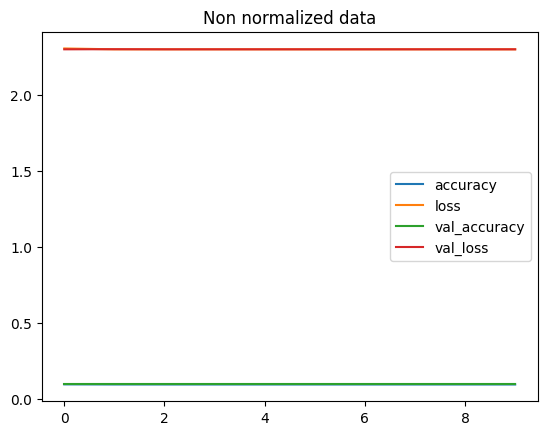

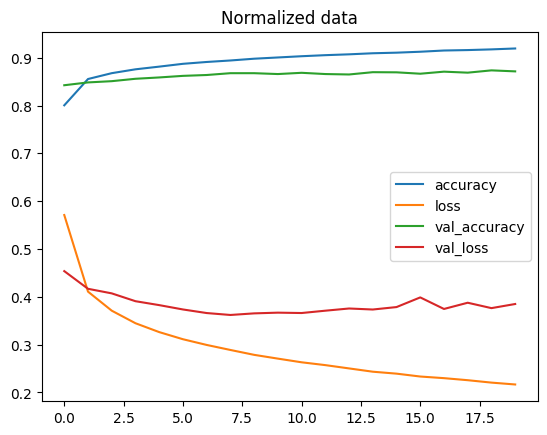

In [13]:
pd.DataFrame(history.history).plot(title="Non normalized data")
pd.DataFrame(history_2.history).plot(title="Normalized data")

In [14]:
tf.random.set_seed(42)

model_3 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(16, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

model_3.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10 ** (epoch / 20))

find_lr_history = model_3.fit(train_data, train_labels, epochs=40, callbacks=[lr_scheduler])

Epoch 1/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 638us/step - accuracy: 0.8143 - loss: 0.5287 - learning_rate: 0.0010
Epoch 2/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step - accuracy: 0.8613 - loss: 0.3870 - learning_rate: 0.0011
Epoch 3/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step - accuracy: 0.8709 - loss: 0.3534 - learning_rate: 0.0013
Epoch 4/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 615us/step - accuracy: 0.8770 - loss: 0.3345 - learning_rate: 0.0014
Epoch 5/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 657us/step - accuracy: 0.8825 - loss: 0.3203 - learning_rate: 0.0016
Epoch 6/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 613us/step - accuracy: 0.8850 - loss: 0.3105 - learning_rate: 0.0018
Epoch 7/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 639us/step - accuracy: 0.8870 - loss: 0.3040 - learning_rate: 0.0020
Epoch 8/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step - accuracy: 0.8874 - loss: 0.3010 - learning_rate: 0.0022
Epoch 9/40
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 711us/step - accuracy: 0.8882 - loss: 0.296

Text(0.5, 1.0, 'Finding the ideal learning rate')

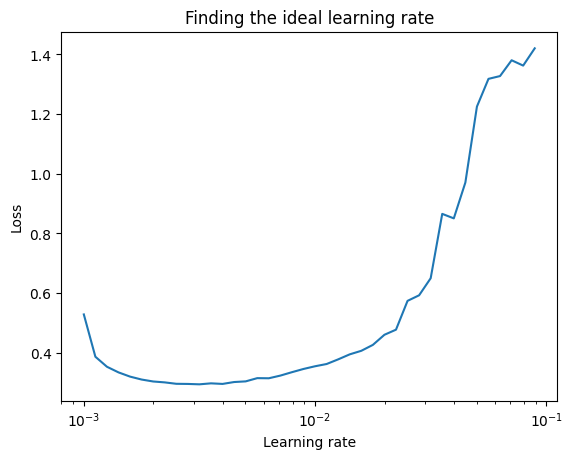

In [15]:
lrs = 1e-3 * (10 ** (np.arange(40) / 20))
plt.semilogx(lrs, find_lr_history.history['loss'])
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.title("Finding the ideal learning rate")

In [16]:
tf.random.set_seed(42)

model_4 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(16, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

model_4.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(3e-3),
                metrics=['accuracy'])

history_4 = model_4.fit(train_data, train_labels, epochs=20, validation_data=(test_data, test_labels))


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 796us/step - accuracy: 0.8205 - loss: 0.5006 - val_accuracy: 0.8464 - val_loss: 0.4210
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 751us/step - accuracy: 0.8603 - loss: 0.3865 - val_accuracy: 0.8541 - val_loss: 0.3936
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - accuracy: 0.8705 - loss: 0.3571 - val_accuracy: 0.8565 - val_loss: 0.3966
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step - accuracy: 0.8754 - loss: 0.3388 - val_accuracy: 0.8524 - val_loss: 0.4010
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 740us/step - accuracy: 0.8804 - loss: 0.3230 - val_accuracy: 0.8583 - val_loss: 0.3918
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 741us/step - accuracy: 0.8844 - loss: 0.3131 - val_accuracy: 0.8590 - val_loss: 0.3970
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step - accuracy: 0.8882 - loss: 0.3009 - val_accuracy: 0.8569 - val_loss: 0.4038
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 738us/step - accuracy: 0.8917 -

In [17]:
import itertools
from sklearn.metrics import confusion_matrix

def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    n_classes = cm.shape[0]
    fig, ax = plt.subplots(figsize=figsize)
    cax = ax.matshow(cm, cmap=plt.cm.Blues)
    fig.colorbar(cax)
    if classes:
        labels = classes
    else:
        labels = np.arange(cm.shape[0])
    ax.set(title="Confusion matrix",
           xlabel="Predicted label",
           ylabel="True label",
           xticks=np.arange(n_classes),
           yticks=np.arange(n_classes),
           xticklabels=labels,
           yticklabels=labels)
    ax.xaxis.set_label_position("bottom")
    threshold = (cm.max() + cm.min()) / 2
    for i, j in itertools.product(range(n_classes), range(n_classes)):
        plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j] * 100:.1f})",
                 horizontalalignment="center",
                 color="white" if cm[i, j] > threshold else "black",
                 size=text_size)

In [18]:
y_probs = model_4.predict(test_data)
y_probs[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 375us/step


array([[8.08167577e-09, 3.81677578e-10, 1.63303127e-09, 3.83328960e-08,
        2.30147023e-07, 1.30878641e-06, 9.50958964e-11, 4.95695975e-04,
        4.49964371e-11, 9.99502599e-01],
       [7.54135908e-06, 1.95700864e-13, 9.98201787e-01, 4.86061197e-07,
        1.72331650e-03, 1.39195891e-30, 6.69252695e-05, 0.00000000e+00,
        1.29750973e-12, 0.00000000e+00],
       [8.76049829e-13, 9.99999940e-01, 6.91949022e-21, 8.86469804e-12,
        1.51842620e-16, 0.00000000e+00, 1.07662737e-15, 1.68784310e-25,
        7.84558246e-17, 9.35993554e-38],
       [1.45011656e-08, 9.99999225e-01, 5.33065475e-12, 5.69838789e-07,
        2.65258038e-09, 1.26591514e-26, 1.80360049e-09, 5.64535813e-16,
        6.17991915e-08, 6.01567025e-23],
       [2.01489553e-01, 7.50438176e-07, 4.10237610e-01, 1.75964013e-02,
        1.69192757e-02, 6.77041687e-11, 3.53711694e-01, 1.51372887e-16,
        4.48186620e-05, 4.99264649e-12]], dtype=float32)

In [19]:
y_probs[0].argmax(), class_names[y_probs[0].argmax()]

(np.int64(9), 'Ankle boot')

In [20]:
y_preds = y_probs.argmax(axis=1)
y_preds[:10]

array([9, 2, 1, 1, 2, 1, 4, 6, 5, 7])

In [21]:
confusion_matrix(y_true=test_labels, y_pred=y_preds)

array([[812,   4,  22,  33,   3,   2, 119,   0,   5,   0],
       [  3, 972,   2,  14,   5,   0,   4,   0,   0,   0],
       [ 16,   1, 816,  12, 116,   0,  38,   0,   1,   0],
       [ 10,   7,  14, 882,  44,   2,  41,   0,   0,   0],
       [  0,   0, 100,  26, 850,   0,  23,   0,   1,   0],
       [  1,   0,   0,   0,   0, 953,   0,  26,   2,  18],
       [100,   1, 141,  28, 136,   0, 586,   0,   8,   0],
       [  0,   1,   0,   0,   0,  15,   0, 973,   0,  11],
       [  5,   0,   4,   9,  20,   2,   7,   4, 948,   1],
       [  0,   0,   0,   0,   0,  10,   1,  67,   0, 922]])

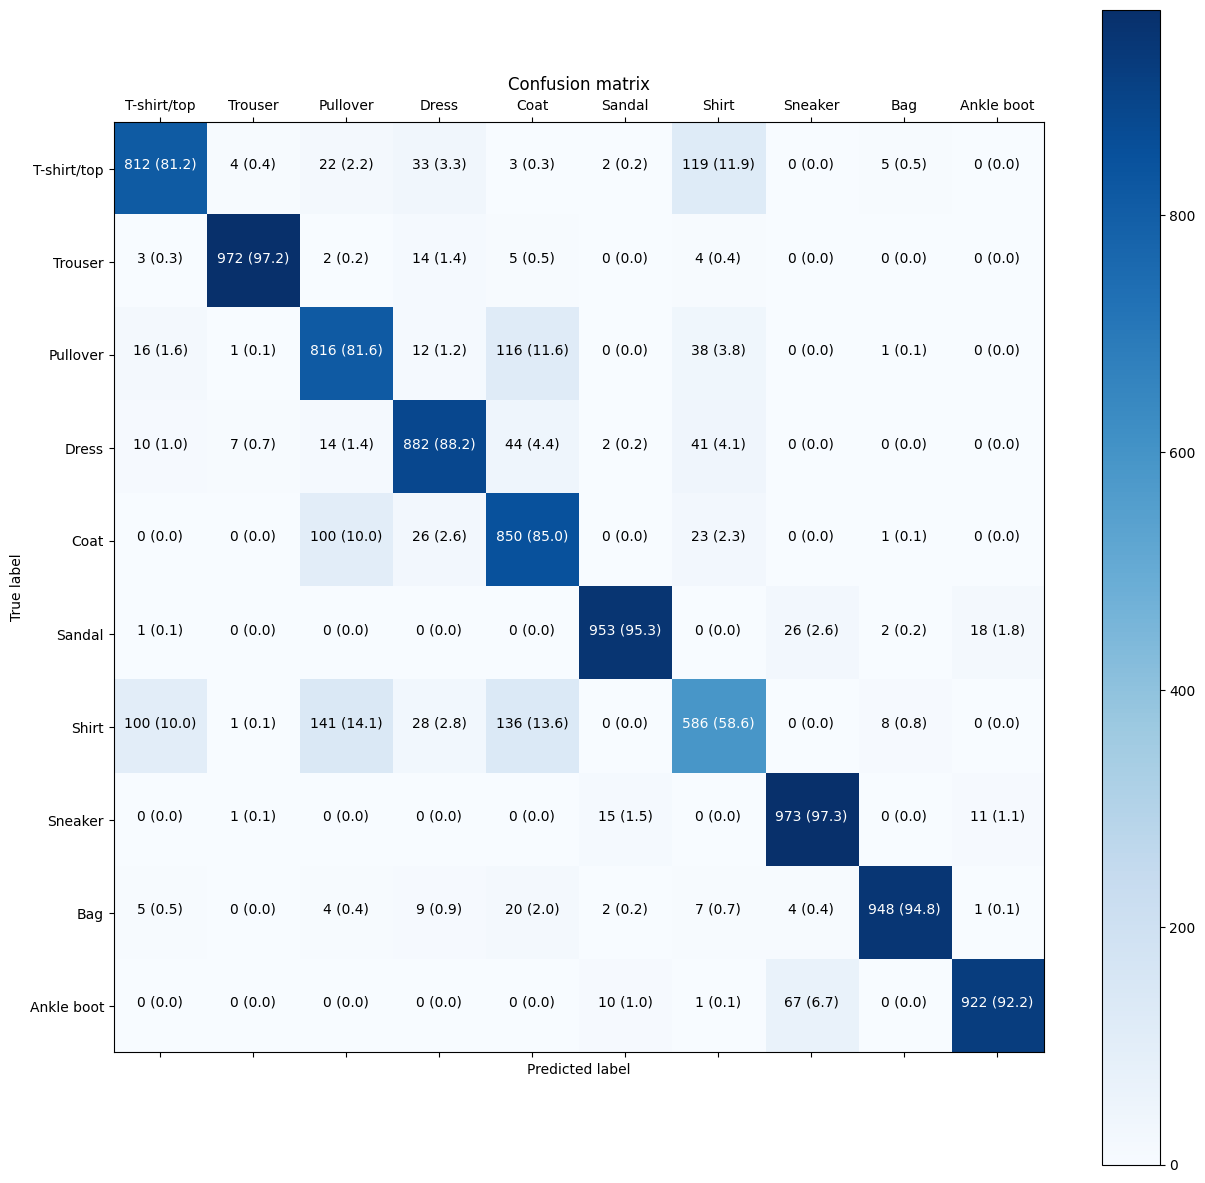

In [22]:
make_confusion_matrix(y_true=test_labels,
                      y_pred=y_preds,
                      classes=class_names,
                      figsize=(15, 15),
                      text_size=10)

In [25]:
def plot_random_image(model, images, true_labels, classes):
    i = random.randint(0, len(images))
    target_image = images[i]
    pred_probs = model_4.predict(target_image.reshape(1, 28, 28))
    pred_label = classes[pred_probs.argmax()]
    true_label = classes[true_labels[i]]
    plt.imshow(target_image, cmap=plt.cm.binary)
    if pred_label == true_label:
        color = "green"
    else:
        color = "red"
    plt.xlabel("Pred: {} {:.2f}% True: {}".format(pred_label, 
                                                   100 * tf.reduce_max(pred_probs),
                                                   true_label), color=color)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


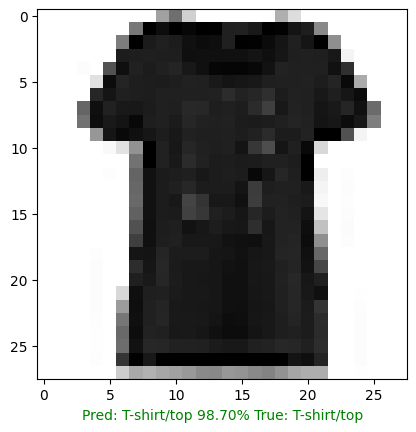

In [26]:
plot_random_image(model_4, test_data, test_labels, class_names)